# Clustering Jerárquico

Este notebook implementa hierarchical clustering basado en geographic location, similar a K-means

## 1. Configuración e Importaciones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist, squareform
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
import pickle
from datetime import datetime
import os
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


## 2. Configuración

In [2]:
# File paths
DATA_FILE = '../datos/filtered_amss/sv_12_2023_location_features_amss.csv'
OUTPUT_DIR = 'results_hierarchical'
MODELS_DIR = os.path.join(OUTPUT_DIR, 'models')

# Hierarchical clustering parameters
LINKAGE_METHOD = 'ward'  # Options: 'ward', 'complete', 'average', 'single'
DISTANCE_METRIC = 'euclidean'  # For ward, must be euclidean
OPTIMAL_K = 3  # For business rules, or None to auto-detect
MIN_VISITORS = 5  # Minimum unique visitors to include location

# Create directories
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)

print("Configuration:")
print(f"  Data file: {DATA_FILE}")
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Linkage method: {LINKAGE_METHOD}")
print(f"  Target clusters: {OPTIMAL_K if OPTIMAL_K else 'Auto-detect'}")

Configuration:
  Data file: ../datos/filtered_amss/sv_12_2023_location_features_amss.csv
  Output directory: results_hierarchical
  Linkage method: ward
  Target clusters: 3


## 3. Load Data

In [3]:
# Load data
df = pd.read_csv(DATA_FILE)

print(f"Datos cargados: {len(df):,} lugares")
print(f"Características: {len(df.columns)} columns")

# Filter by minimum visitors
df_filtered = df[df['unique_devices_count'] >= MIN_VISITORS].copy()

print(f"\nAfter filtering (>= {MIN_VISITORS} visitors): {len(df_filtered):,} lugares")
df_filtered.head()

Datos cargados: 14,697 lugares
Características: 65 columns

After filtering (>= 5 visitors): 7,260 lugares


,osm_id,clase,nombre,geometry_wkt,unique_visits_weekday,footfall_avg_per_day,unique_devices_count,unique_device_by_timeblock_morning,unique_device_by_timeblock_afternoon,unique_device_by_timeblock_evening,...,dwell_time_median,dwell_time_weekday_mean,dwell_time_weekend_mean,days_active,avg_visits_per_active_day,std_visits_per_day,weekend_to_weekday_ratio,morning_to_evening_ratio,repeat_to_unique_ratio,avg_visits_per_device
0,400846765,bank,Banco Industrial,"POLYGON ((-89.2383563 13.6947575, -89.238334 1...",12,1.714286,9,4,7,1,...,0.0,10.112500,NaN,7,4.000000,3.366502,0.000000,4.00,2.111111,3.111111
1,400002511,residential,Palo Alto,"POLYGON ((-89.2576736 13.7101421, -89.2571881 ...",17,1.411765,15,2,7,10,...,0.0,48.552941,41.983333,17,4.000000,4.415880,0.411765,0.20,3.533333,4.533333
2,556395539,parking,parking,"POLYGON ((-89.2001489 13.7046549, -89.200128 1...",12,1.300000,11,8,4,0,...,0.0,0.033333,0.000000,10,1.400000,0.699206,0.083333,NaN,0.272727,1.272727
3,664504345,grass,grass,"POLYGON ((-89.2407758 13.7197677, -89.2406638 ...",12,1.153846,14,4,8,2,...,0.0,0.000000,0.000000,13,1.153846,0.375534,0.250000,2.00,0.071429,1.071429
4,312566571,building,Fusal,"POLYGON ((-89.2578833 13.6617643, -89.2577445 ...",9,1.153846,14,5,6,4,...,0.0,0.000000,5.975000,13,1.769231,1.363442,0.666667,1.25,0.642857,1.642857


## 4. Extracción de caracterisiticas geograficas

Para clusterización de ubiaciones, se extraen los centroides de la geometry_wkt.

In [4]:
from shapely import wkt

def extract_centroid(geometry_wkt):
    """Extract centroid (lat, lon) from WKT geometry."""
    try:
        geom = wkt.loads(geometry_wkt)
        centroid = geom.centroid
        return centroid.y, centroid.x  # lat, lon
    except:
        return None, None

# Extract centroids
print("Extracting centroids from geometries...")
df_filtered[['latitude', 'longitude']] = df_filtered['geometry_wkt'].apply(
    lambda x: pd.Series(extract_centroid(x))
)

# Remove any invalid geometries
df_filtered = df_filtered.dropna(subset=['latitude', 'longitude'])

print(f"\n✓ {len(df_filtered):,} lugares with valid coordinates")
print(f"Latitude range: {df_filtered['latitude'].min():.6f} to {df_filtered['latitude'].max():.6f}")
print(f"Longitude range: {df_filtered['longitude'].min():.6f} to {df_filtered['longitude'].max():.6f}")

Extracting centroids from geometries...

✓ 7,260 lugares with valid coordinates
Latitude range: 13.550097 to 13.890260
Longitude range: -89.350379 to -89.098645


## 5. Preparando Matriz de features


In [5]:
# Prepare clustering dataset
# Handle missing values and filter valid lugares

df_filtered = df.copy()

# Filter lugares with minimum activity (at least 5 unique visitors)
min_visitors = 10
df_filtered = df_filtered[df_filtered['visits_total'] >= min_visitors]

print(f"Places with >= {min_visitors} visitors: {len(df_filtered):,}")

Places with >= 10 visitors: 7,253


In [7]:
# Check for missing values
missing = df_filtered.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

if len(missing) > 0:
    print("\nColumns with missing values:")
    print(missing)
    print(f"\nTotal lugares: {len(df_filtered)}")
else:
    print("\n✓ No missing values!")


Columns with missing values:
avg_days_to_return          940
morning_to_evening_ratio    549
peak_hour_weekend           415
dwell_time_weekend_mean     415
peak_hour_weekday            30
weekend_to_weekday_ratio     30
dwell_time_weekday_mean      30
std_visits_per_day           22
dwell_time_std               19
dtype: int64

Total lugares: 7253


In [8]:
# Definir columnas para imputar con 0
columns_impute_zero = [
    'avg_days_to_return',
    'morning_to_evening_ratio', 
    'dwell_time_weekend_mean',
    'weekend_to_weekday_ratio',
    'dwell_time_weekday_mean',
    'std_visits_per_day',
    'dwell_time_std'
]

# Definir columnas para imputar con mediana
columns_impute_median = [
    'peak_hour_weekday',
    'peak_hour_weekend'
]

for col in columns_impute_zero:
    if col in df_filtered.columns:
        df_filtered[col] = df_filtered[col].fillna(0)
        print(f"✓ Imputado con 0: {col}")

# Imputar con mediana
for col in columns_impute_median:
    if col in df_filtered.columns:
        median_value = df_filtered[col].median()
        df_filtered[col] = df_filtered[col].fillna(median_value)
        print(f"✓ Imputado con mediana ({median_value:.2f}): {col}")

# Verificar valores nulos restantes
missing_after = df_filtered.isnull().sum()
missing_after = missing_after[missing_after > 0]

if len(missing_after) > 0:
    print(f"\n⚠️  Columnas con valores nulos restantes:")
    print(missing_after)
else:
    print(f"\n✓ No hay valores nulos en df_filtered")

✓ Imputado con 0: avg_days_to_return
✓ Imputado con 0: morning_to_evening_ratio
✓ Imputado con 0: dwell_time_weekend_mean
✓ Imputado con 0: weekend_to_weekday_ratio
✓ Imputado con 0: dwell_time_weekday_mean
✓ Imputado con 0: std_visits_per_day
✓ Imputado con 0: dwell_time_std
✓ Imputado con mediana (12.00): peak_hour_weekday
✓ Imputado con mediana (11.00): peak_hour_weekend

✓ No hay valores nulos en df_filtered


In [9]:
exclude_columns = ['osm_id', 'clase', 'nombre', 'geometry_wkt', 'visits_by_hour_0', 'visits_by_hour_1', 'visits_by_hour_2',
       'visits_by_hour_3', 'visits_by_hour_4', 'visits_by_hour_5',
       'visits_by_hour_6', 'visits_by_hour_7', 'visits_by_hour_8',
       'visits_by_hour_9', 'visits_by_hour_10', 'visits_by_hour_11',
       'visits_by_hour_12', 'visits_by_hour_13', 'visits_by_hour_14',
       'visits_by_hour_15', 'visits_by_hour_16', 'visits_by_hour_17',
       'visits_by_hour_18', 'visits_by_hour_19', 'visits_by_hour_20',
       'visits_by_hour_21', 'visits_by_hour_22', 'visits_by_hour_23',
       'visits_by_day_0', 'visits_by_day_1', 'visits_by_day_2',
       'visits_by_day_3', 'visits_by_day_4', 'visits_by_day_5',
       'visits_by_day_6']

columns_high_corr = ['avg_visits_per_device','repeat_to_unique_ratio','avg_visits_per_active_day','footfall_avg_per_day','unique_device_by_timeblock_afternoon','dwell_time_weekday_mean','revisit_rate_7d','unique_device_by_timeblock_morning','unique_device_by_timeblock_evening','revisit_rate_3d','std_visits_per_day','dwell_time_weekend_mean','dwell_time_std','unique_visits_weekday','dwell_time_mean','visits_per_device_mean']

correlation_columns_2 = [col for col in df.columns if col not in exclude_columns+columns_high_corr]

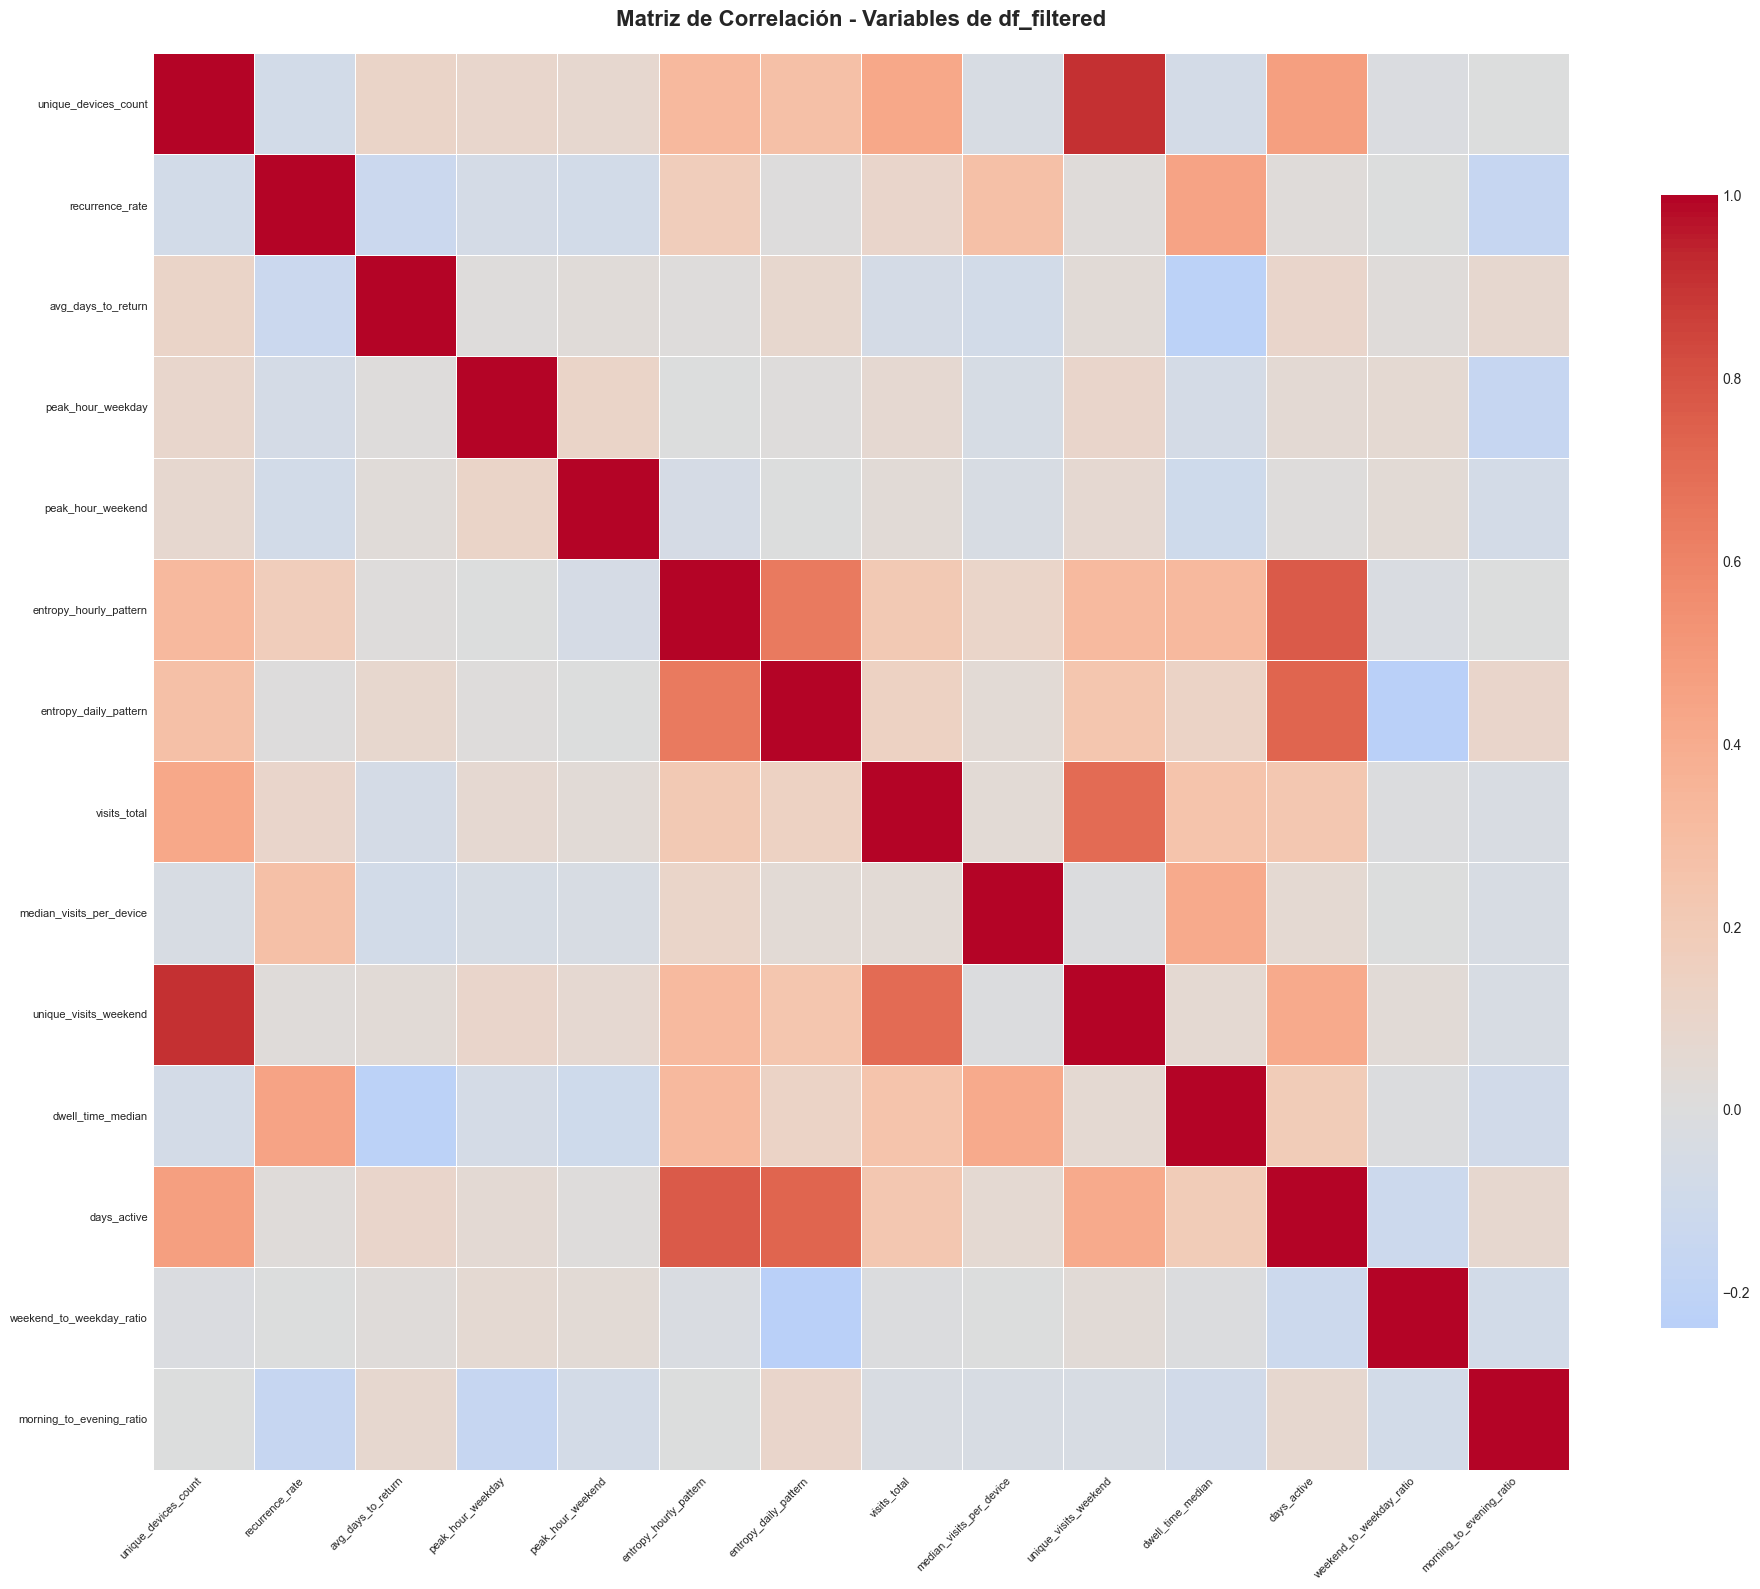

In [10]:
correlation_matrix = df_filtered[correlation_columns_2].corr()

plt.figure(figsize=(20, 16))
sns.heatmap(correlation_matrix, cmap='coolwarm', center=0, 
            annot=False, square=True, linewidths=0.5, 
            cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables de df_filtered', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('results/correlation_matrix_full.png', dpi=300, bbox_inches='tight')
plt.show()


In [13]:
from shapely import wkt

def extract_centroid(geometry_wkt):
    """Extract centroid (lat, lon) from WKT geometry."""
    try:
        geom = wkt.loads(geometry_wkt)
        centroid = geom.centroid
        return centroid.y, centroid.x  # lat, lon
    except:
        return None, None

# Extract centroids
print("Extracting centroids from geometries...")
df_filtered[['latitude', 'longitude']] = df_filtered['geometry_wkt'].apply(
    lambda x: pd.Series(extract_centroid(x))
)

# Remove any invalid geometries
df_filtered = df_filtered.dropna(subset=['latitude', 'longitude'])

print(f"\n✓ {len(df_filtered):,} lugares with valid coordinates")
print(f"Latitude range: {df_filtered['latitude'].min():.6f} to {df_filtered['latitude'].max():.6f}")
print(f"Longitude range: {df_filtered['longitude'].min():.6f} to {df_filtered['longitude'].max():.6f}")

Extracting centroids from geometries...

✓ 7,253 lugares with valid coordinates
Latitude range: 13.550097 to 13.896838
Longitude range: -89.350379 to -89.098645


In [15]:
CLUSTERING_FEATURES = correlation_columns_2

print(f"\nUsing {len(CLUSTERING_FEATURES)} features for clustering")

# Extract feature matrix
X = df_filtered[CLUSTERING_FEATURES].copy()

# Handle remaining missing values
print(f"\nMissing values before imputation:")
print(X.isnull().sum()[X.isnull().sum() > 0])


print(f"\n✓ Feature matrix prepared: {X.shape}")
print(f"  {X.shape[0]:,} lugares × {X.shape[1]} features")


Using 14 features for clustering

Missing values before imputation:
Series([], dtype: int64)

✓ Feature matrix prepared: (7253, 14)
  7,253 lugares × 14 features


## 6. Estandarización/Normalización


In [16]:
# Standardize features (mean=0, std=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("✓ Características standardized")
print(f"  Shape: {X_scaled.shape}")
print(f"  Mean: {X_scaled.mean():.6f}")
print(f"  Std: {X_scaled.std():.6f}")

# Show before/after standardization for one feature
sample_feature = CLUSTERING_FEATURES[0]
print(f"\nExample - {sample_feature}:")
print(f"  Before: mean={X[sample_feature].mean():.2f}, std={X[sample_feature].std():.2f}")
print(f"  After:  mean={X_scaled[:, 0].mean():.2f}, std={X_scaled[:, 0].std():.2f}")

✓ Características standardized
  Shape: (7253, 14)
  Mean: -0.000000
  Std: 1.000000

Example - unique_devices_count:
  Before: mean=39.29, std=84.10
  After:  mean=-0.00, std=1.00


## 7. Hierarchical Clustering

### 7.1 Compute Linkage Matrix

In [17]:
print("="*70)
print("COMPUTING HIERARCHICAL CLUSTERING")
print("="*70)
print(f"\nLinkage method: {LINKAGE_METHOD}")
print(f"Distance metric: {DISTANCE_METRIC}")
print(f"Number of observations: {len(X_scaled):,}")
print("\nThis may take a few minutes for large datasets...\n")

# Compute linkage matrix
linkage_matrix = linkage(X_scaled, method=LINKAGE_METHOD, metric=DISTANCE_METRIC)

print("✓ Linkage matrix computed!")
print(f"  Shape: {linkage_matrix.shape}")
print(f"  Max distance: {linkage_matrix[:, 2].max():.2f}")

COMPUTING HIERARCHICAL CLUSTERING

Linkage method: ward
Distance metric: euclidean
Number of observations: 7,253

This may take a few minutes for large datasets...

✓ Linkage matrix computed!
  Shape: (7252, 4)
  Max distance: 148.41


### 7.2 Dendrogram Visualization

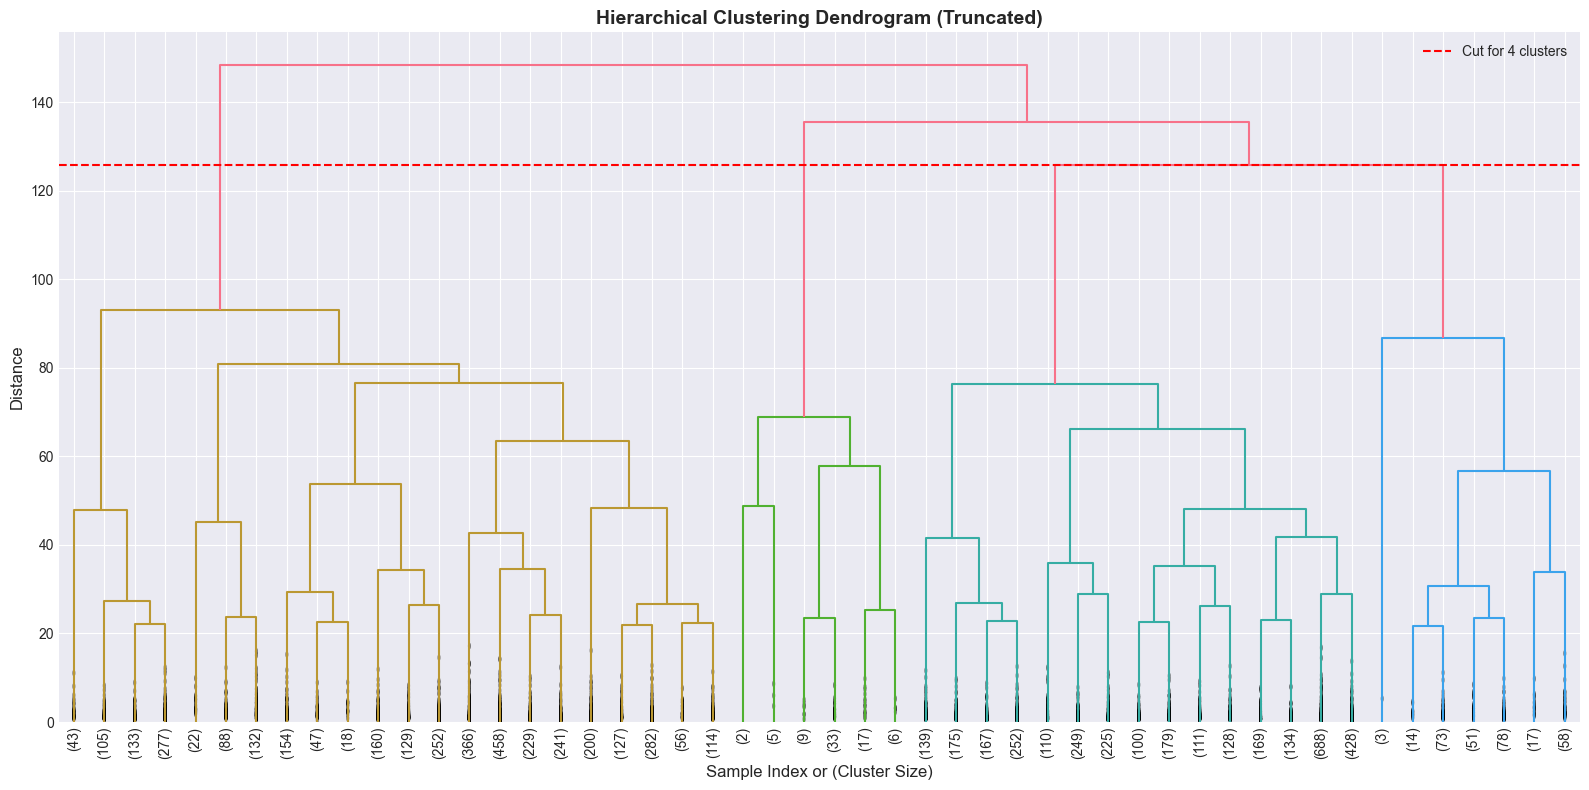

✓ Saved: results_hierarchical/dendrogram_truncated.png


In [21]:
OPTIMAL_K=4
# Full dendrogram (truncated for visualization)
plt.figure(figsize=(16, 8))
dendrogram(
    linkage_matrix,
    truncate_mode='lastp',  # Show only last p merged clusters
    p=50,  # Show last 50 merges
    leaf_font_size=10,
    show_contracted=True
)
plt.xlabel('Sample Index or (Cluster Size)', fontsize=12)
plt.ylabel('Distance', fontsize=12)
plt.title('Hierarchical Clustering Dendrogram (Truncated)', 
          fontsize=14, fontweight='bold')
plt.axhline(y=linkage_matrix[-OPTIMAL_K+1, 2] if OPTIMAL_K else 0, 
            c='r', linestyle='--', label=f'Cut for {OPTIMAL_K} clusters')
plt.legend()
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/dendrogram_truncated.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Saved: {OUTPUT_DIR}/dendrogram_truncated.png")

### 7.3 Número Optimo de Clusters

Finding optimal number of clusters...

K=2: Silhouette=0.1319, DB=2.3635, CH=882.09
K=3: Silhouette=0.1347, DB=1.8862, CH=899.96
K=4: Silhouette=0.1394, DB=1.6719, CH=925.56
K=5: Silhouette=0.1440, DB=1.6072, CH=851.17
K=6: Silhouette=0.1458, DB=1.3887, CH=803.48
K=7: Silhouette=0.1478, DB=1.4047, CH=768.65
K=8: Silhouette=0.1460, DB=1.5128, CH=742.59
K=9: Silhouette=0.1150, DB=1.5514, CH=730.51
K=10: Silhouette=0.1161, DB=1.4997, CH=713.31

Métricas por número de clústeres (hierarchical):
    k  silhouette  davies_bouldin  calinski_harabasz
0   2    0.131940        2.363493         882.089123
1   3    0.134664        1.886244         899.963293
2   4    0.139407        1.671854         925.558404
3   5    0.144048        1.607241         851.170481
4   6    0.145804        1.388709         803.479816
5   7    0.147777        1.404682         768.650267
6   8    0.145988        1.512817         742.593416
7   9    0.114973        1.551362         730.512314
8  10    0.116051        1.4

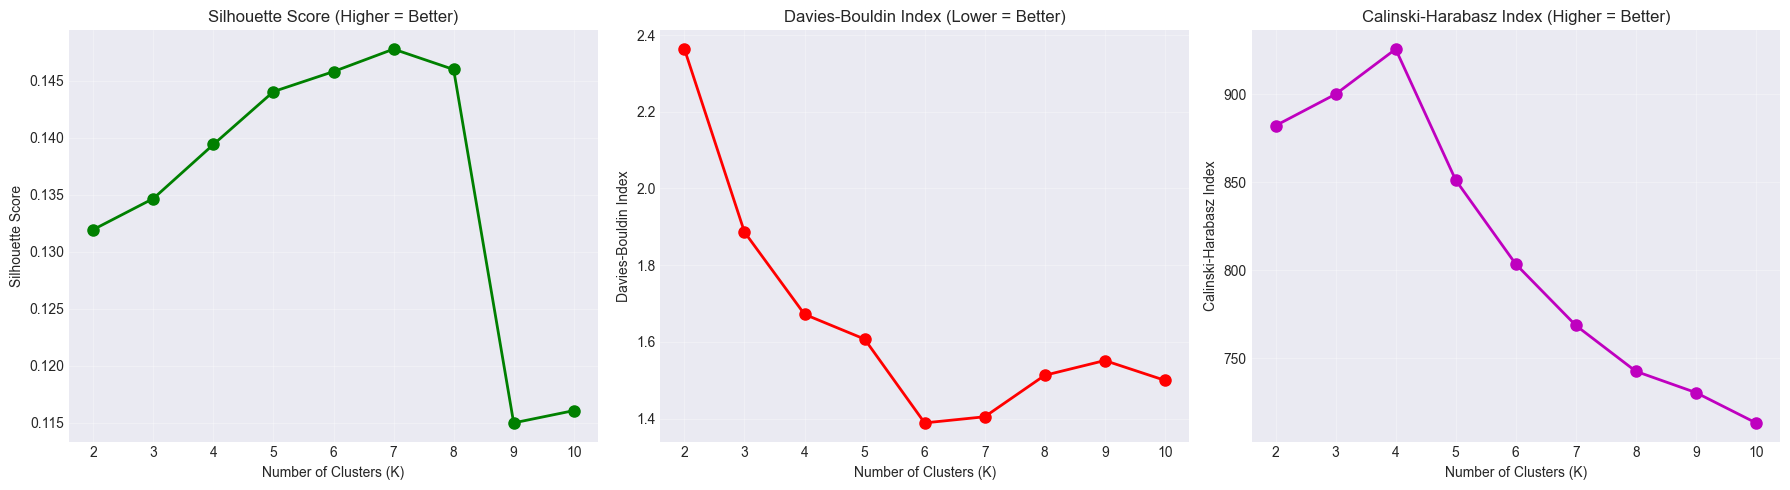


✓ Optimal K selected: 7


In [19]:
OPTIMAL_K=None
# If OPTIMAL_K not specified, find it automatically
if OPTIMAL_K is None:
    print("Finding optimal number of clusters...\n")
    
    k_range = range(2, 11)
    silhouettes = []
    davies_bouldins = []
    calinski_harabaszs = []
    
    for k in k_range:
        labels = fcluster(linkage_matrix, k, criterion='maxclust')
        
        sil = silhouette_score(X_scaled, labels)
        db = davies_bouldin_score(X_scaled, labels)
        ch = calinski_harabasz_score(X_scaled, labels)
        
        silhouettes.append(sil)
        davies_bouldins.append(db)
        calinski_harabaszs.append(ch)
        
        print(f"K={k}: Silhouette={sil:.4f}, DB={db:.4f}, CH={ch:.2f}")
    
    # Crear DataFrame con las métricas por K
    df_hier_metrics = pd.DataFrame({
        "k": list(k_range),
        "silhouette": silhouettes,
        "davies_bouldin": davies_bouldins,
        "calinski_harabasz": calinski_harabaszs
    })
    print("\nMétricas por número de clústeres (hierarchical):")
    print(df_hier_metrics)

    # Plot metrics
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    axes[0].plot(k_range, silhouettes, 'go-', linewidth=2, markersize=8)
    axes[0].set_xlabel('Number of Clusters (K)')
    axes[0].set_ylabel('Silhouette Score')
    axes[0].set_title('Silhouette Score (Higher = Better)')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(k_range, davies_bouldins, 'ro-', linewidth=2, markersize=8)
    axes[1].set_xlabel('Number of Clusters (K)')
    axes[1].set_ylabel('Davies-Bouldin Index')
    axes[1].set_title('Davies-Bouldin Index (Lower = Better)')
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(k_range, calinski_harabaszs, 'mo-', linewidth=2, markersize=8)
    axes[2].set_xlabel('Number of Clusters (K)')
    axes[2].set_ylabel('Calinski-Harabasz Index')
    axes[2].set_title('Calinski-Harabasz Index (Higher = Better)')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/optimal_k_analysis_hierarchical.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    # Select optimal K (ejemplo usando máximo Silhouette)
    OPTIMAL_K = df_hier_metrics.loc[df_hier_metrics["silhouette"].idxmax(), "k"]
    print(f"\n✓ Optimal K selected: {OPTIMAL_K}")
else:
    print(f"Using specified K = {OPTIMAL_K}")

In [22]:
OPTIMAL_K

4

## 8. Extracción final de clústers

In [23]:
# Cut dendrogram to get k clusters
cluster_labels = fcluster(linkage_matrix, OPTIMAL_K, criterion='maxclust')

# Convert to 0-indexed
cluster_labels = cluster_labels - 1

# Add to dataframe
df_filtered['cluster'] = cluster_labels

print("✓ Clusters assigned!")
print(f"\nCluster distribution:")
cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
for cluster_id, count in cluster_counts.items():
    pct = 100 * count / len(cluster_labels)
    print(f"  Cluster {cluster_id}: {count:4d} lugares ({pct:5.2f}%)")

✓ Clusters assigned!

Cluster distribution:
  Cluster 0: 3633 lugares (50.09%)
  Cluster 1:   72 lugares ( 0.99%)
  Cluster 2: 3254 lugares (44.86%)
  Cluster 3:  294 lugares ( 4.05%)


## 9. Evaluación

In [24]:
# Calculate evaluation metrics
final_silhouette = silhouette_score(X_scaled, cluster_labels)
final_db = davies_bouldin_score(X_scaled, cluster_labels)
final_ch = calinski_harabasz_score(X_scaled, cluster_labels)

print("="*70)
print("CLUSTERING QUALITY EVALUATION")
print("="*70)
print(f"\nNumber of Clusters: {OPTIMAL_K}")
print(f"Number of Places: {len(cluster_labels):,}")
print(f"\nMetrics:")
print(f"  Silhouette Score:        {final_silhouette:.4f}")

if final_silhouette > 0.7:
    print(f"    → Excellent clustering quality")
elif final_silhouette > 0.5:
    print(f"    → Good clustering quality")
elif final_silhouette > 0.25:
    print(f"    → Acceptable clustering quality")
else:
    print(f"    → Weak clustering structure")

print(f"\n  Davies-Bouldin Index:    {final_db:.4f}")
print(f"    → Lower is better")

print(f"\n  Calinski-Harabasz Index: {final_ch:.2f}")
print(f"    → Higher is better")
print("="*70)

CLUSTERING QUALITY EVALUATION

Number of Clusters: 4
Number of Places: 7,253

Metrics:
  Silhouette Score:        0.1394
    → Weak clustering structure

  Davies-Bouldin Index:    1.6719
    → Lower is better

  Calinski-Harabasz Index: 925.56
    → Higher is better


## 10. Cluster Profiling

In [26]:
# Calculate cluster profiles (mean values for each feature)
cluster_profiles = df_filtered.groupby('cluster')[CLUSTERING_FEATURES].mean()

# Also get median and std
cluster_median = df_filtered.groupby('cluster')[CLUSTERING_FEATURES].median()
cluster_std = df_filtered.groupby('cluster')[CLUSTERING_FEATURES].std()

print("Cluster profiles (mean values):")
cluster_profiles

Cluster profiles (mean values):


,unique_devices_count,recurrence_rate,avg_days_to_return,peak_hour_weekday,peak_hour_weekend,entropy_hourly_pattern,entropy_daily_pattern,visits_total,median_visits_per_device,unique_visits_weekend,dwell_time_median,days_active,weekend_to_weekday_ratio,morning_to_evening_ratio
cluster,,,,,,,,,,,,,,
0,10.712634,0.262770,3.070288,11.924305,10.966969,2.038332,1.289875,44.618497,3.077897,4.171484,21.086118,11.213047,0.468300,1.907573
1,576.430556,0.346929,3.977131,15.750000,13.333333,2.934284,1.772787,11835.861111,3.319444,380.486111,198.056019,30.000000,0.449973,1.087631
2,61.723725,0.202257,5.847487,12.727105,11.430854,2.565645,1.635938,299.559619,1.803626,25.343884,24.767522,23.070375,0.391240,1.654258
3,12.700680,0.676021,1.314860,10.261905,8.629252,3.009976,1.720894,1480.183673,87.319728,23.278912,898.162642,25.431973,0.404679,1.045128


## 11. Almacenando resultados

In [28]:
# Export clustered data
output_file = f'{OUTPUT_DIR}/hierarchical_clustered_places.csv'
df_filtered.to_csv(output_file, index=False)
print(f"✓ Clustered lugares saved: {output_file}")

# Export cluster profiles
profiles = df_filtered.groupby('cluster')[CLUSTERING_FEATURES].mean()
profiles_file = f'{OUTPUT_DIR}/hierarchical_cluster_profiles.csv'
profiles.to_csv(profiles_file)
print(f"✓ Cluster profiles saved: {profiles_file}")

# Save linkage matrix
linkage_file = os.path.join(MODELS_DIR, 'linkage_matrix.pkl')
with open(linkage_file, 'wb') as f:
    pickle.dump(linkage_matrix, f)
print(f"✓ Linkage matrix saved: {linkage_file}")

# Save complete model package
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_package = {
    'linkage_matrix': linkage_matrix,
    'scaler': scaler,
    'optimal_k': OPTIMAL_K,
    'linkage_method': LINKAGE_METHOD,
    'distance_metric': DISTANCE_METRIC,
    'feature_names': CLUSTERING_FEATURES,
    'cluster_labels': cluster_labels,
    'evaluation_metrics': {
        'silhouette_score': final_silhouette,
        'davies_bouldin_score': final_db,
        'calinski_harabasz_score': final_ch
    },
    'metadata': {
        'timestamp': timestamp,
        'n_places': len(df_filtered),
        'n_features': len(CLUSTERING_FEATURES)
    }
}

package_file = os.path.join(MODELS_DIR, f'hierarchical_complete_{timestamp}.pkl')
with open(package_file, 'wb') as f:
    pickle.dump(model_package, f)
print(f"✓ Completo package saved: {package_file}")

# Save as latest
latest_file = os.path.join(MODELS_DIR, 'hierarchical_latest.pkl')
with open(latest_file, 'wb') as f:
    pickle.dump(model_package, f)
print(f"✓ Latest model saved: {latest_file}")

✓ Clustered lugares saved: results_hierarchical/hierarchical_clustered_places.csv
✓ Cluster profiles saved: results_hierarchical/hierarchical_cluster_profiles.csv
✓ Linkage matrix saved: results_hierarchical\models\linkage_matrix.pkl
✓ Completo package saved: results_hierarchical\models\hierarchical_complete_20251123_013729.pkl
✓ Latest model saved: results_hierarchical\models\hierarchical_latest.pkl


## 12. Visualización interactiva con Folium

In [30]:
import folium
import math
import os

print("Creando interactive maps...")

# Parámetros AJUSTABLES
CENTER_LAT = 13.69160454420804
CENTER_LON = -89.23897086471047
RADIUS_KM = 3.0      # radio en km (ajústalo aquí)
ZOOM_START = 17       # nivel de zoom inicial (ajústalo aquí)

print(f"Map center: ({CENTER_LAT:.6f}, {CENTER_LON:.6f}) | Radio = {RADIUS_KM} km | Zoom = {ZOOM_START}")

# Función Haversine para calcular distancia entre dos puntos (en km)
def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0  # Radio de la Tierra en km (aprox)
    phi1, phi2 = math.radians(lat1), math.radians(lat2)
    dphi = math.radians(lat2 - lat1)
    dlambda = math.radians(lon2 - lon1)

    a = math.sin(dphi / 2)**2 + math.cos(phi1) * math.cos(phi2) * math.sin(dlambda / 2)**2
    c = 2 * math.atan2(math.sqrt(a), math.sqrt(1 - a))
    return R * c

# Filtrar df_clustering a lugares dentro del radio RADIUS_KM del centro
df_region = df_filtered.copy()
df_region["dist_km"] = df_region.apply(
    lambda r: haversine_km(CENTER_LAT, CENTER_LON, r["latitude"], r["longitude"]),
    axis=1
)
df_region = df_region[df_region["dist_km"] <= RADIUS_KM].reset_index(drop=True)

print(f"Lugares dentro de {RADIUS_KM} km: {len(df_region)}")

# Crear mapa centrado en la región
m1 = folium.Map(
    location=[CENTER_LAT, CENTER_LON],
    zoom_start=ZOOM_START,
    tiles='OpenStreetMap'
)

# Colores para los clústeres K-means (color del pin)
n_clusters_kmeans = len(df_filtered['cluster'].unique())
cluster_colors = {
    0: 'red',
    1: 'green',
    2: 'blue',
    3: 'orange'
}

# Tamaños de clúster SOLO en la región filtrada
cluster_sizes_viz = df_region['cluster'].value_counts().sort_index()

# --------- PINTAR TODOS LOS PUNTOS (SIN LÍMITE) ---------
for cluster_id in sorted(df_region['cluster'].unique()):
    cluster_data = df_region[df_region['cluster'] == cluster_id]
    color = cluster_colors.get(cluster_id, 'gray')

    for _, row in cluster_data.iterrows():
        # Nombre del local (ajusta al nombre real de tu columna si es diferente)
        place_name = (
            row.get("nombre")
            if "nombre" in row
            else row.get("clase", row.get("osm_id", "N/A"))
        )

        folium.Marker(
            location=[row['latitude'], row['longitude']],
            popup=(
                f"<b>Cluster {cluster_id}</b><br>"
                f"<b>Local:</b> {place_name}<br>"
            ),
            tooltip=f"{place_name} (Cluster {cluster_id})",
            icon=folium.Icon(
                color=color,      # color del pin
                icon="info-sign", # iconito dentro del pin (semi-3D)
                prefix="glyphicon"
            )
        ).add_to(m1)

# Leyenda: color por clúster + ejemplos de nombres de locales
legend_html = f'''
<div style="position: fixed;
    bottom: 50px; right: 50px; width: 260px; max-height: 260px; overflow-y: auto;
    background-color: white; border:2px solid grey; z-index:9999;
    font-size:13px; padding: 10px">
    <p><b>K-Means Clusters (k={n_clusters_kmeans})</b><br>
    Región: radio {RADIUS_KM} km</p>
'''

# Mapeo a colores hex para el cuadrito ■ de la leyenda
color_to_hex = {
    'red': '#FF0000',
    'green': '#00FF00',
    'blue': '#0000FF',
    'orange': '#FFA500',
}

for cluster_id in sorted(df_region['cluster'].unique()):
    color_name = cluster_colors.get(cluster_id, 'gray')
    color_hex = color_to_hex.get(color_name, '#888888')
    size = cluster_sizes_viz.get(cluster_id, 0)

    # Ejemplos de nombres de locales (hasta 3)
    cluster_data = df_region[df_region['cluster'] == cluster_id]
    sample_names = []
    for _, row in cluster_data.head(3).iterrows():
        place_name = (
            row.get("place_name")
            if "place_name" in row
            else row.get("name", row.get("place_id", "N/A"))
        )
        sample_names.append(str(place_name))

    examples_text = ", ".join(sample_names) if sample_names else "N/A"

    legend_html += f'''
    <p>
      <span style="color:{color_hex}">■</span>
      Cluster {cluster_id} ({size:,} lugares)<br>
      <span style="margin-left: 16px; font-size: 12px;">
        Ejemplos: {examples_text}
      </span>
    </p>
    '''

legend_html += '</div>'

m1.get_root().html.add_child(folium.Element(legend_html))

# Guardar mapa
os.makedirs('results', exist_ok=True)
map1_file = f'results/map_jerarquical_clusters_points_region_{RADIUS_KM:.1f}km_zoom{ZOOM_START}.html'
m1.save(map1_file)
print(f"✓ Saved: {map1_file}")

print("\nDisplaying map...")
m1

Creando interactive maps...
Map center: (13.691605, -89.238971) | Radio = 3.0 km | Zoom = 17
Lugares dentro de 3.0 km: 2271
✓ Saved: results/map_jerarquical_clusters_points_region_3.0km_zoom17.html

Displaying map...


### 12.1 Places Heatmap

In [25]:
# Map 2: Heatmap of all lugares
print("Creando Map 2: Places Heatmap...")

m2 = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles='CartoDB positron'
)

# Sample data for heatmap (max 5,000 points for performance)
HEATMAP_SAMPLE_SIZE = 5000
heatmap_sample = df_filtered.sample(min(HEATMAP_SAMPLE_SIZE, len(df_filtered)), random_state=42)

# Prepare heat data
heat_data = [[row['latitude'], row['longitude']] for _, row in heatmap_sample.iterrows()]

# Add heatmap layer
HeatMap(
    heat_data,
    min_opacity=0.3,
    max_zoom=18,
    radius=15,
    blur=20,
    gradient={
        0.0: 'blue',
        0.3: 'lime',
        0.5: 'yellow',
        0.7: 'orange',
        1.0: 'red'
    }
).add_to(m2)

# Save map
map2_file = 'results/map_hierarchical_heatmap.html'
m2.save(map2_file)
print(f"✓ Saved: {map2_file}")

print("\nDisplaying heatmap...")
m2


Creating Map 2: Places Heatmap...
✓ Saved: results/map_hierarchical_heatmap.html

Displaying heatmap...
